In [1]:
import torch
from ase.io import read, write, Trajectory
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
docker build -t lammps:dev \
  --build-arg UID=$(id -u) \
  --build-arg GID=$(id -g) \
  --build-arg USERNAME=lijia \
  -f Dockerfile .

SyntaxError: unexpected character after line continuation character (3597531770.py, line 2)

In [ ]:
from curator.layer import GlobalRescaleShift, Strain, AtomwiseReduce, PairwiseDistance, GradientOutput, RealAgnosticInteractionBlock, RealAgnosticResidualInteractionBlock
from curator.model import NeuralNetworkPotential, MACE
from ase.data import chemical_symbols
import torch

def create_model_from_mace(mace_model, foundation=False):
    input_modules = [Strain(), PairwiseDistance(compute_distance_from_R=True)]
    curator_mace = MACE(
        cutoff=float(mace_model.r_max),
        num_interactions=len(mace_model.interactions),
        correlation=[contraction.correlation for contraction in mace_model.products[0].symmetric_contractions.contractions],
        species=[chemical_symbols[i] for i in mace_model.atomic_numbers],
        hidden_irreps=mace_model.interactions[0].hidden_irreps,
        edge_sh_irreps=mace_model.spherical_harmonics.irreps_out,
        avg_num_neighbors=mace_model.interactions[0].avg_num_neighbors,
        MLP_irreps=mace_model.readouts[-1].hidden_irreps,
        num_basis=len(mace_model.radial_embedding.bessel_fn.bessel_weights),
        power=float(mace_model.radial_embedding.cutoff_fn.p),
        interaction_cls=RealAgnosticResidualInteractionBlock,
        interaction_cls_first=RealAgnosticInteractionBlock if not foundation else RealAgnosticResidualInteractionBlock,
    )

    output_modules = [
        AtomwiseReduce(output_key='energy'),
        GlobalRescaleShift(
            scale_by=float(mace_model.scale_shift.scale),
            shift_by=float(mace_model.scale_shift.shift),
            atomic_energies={
                int(idx): float(e)
                for idx, e in zip(mace_model.atomic_numbers, mace_model.atomic_energies_fn.atomic_energies.squeeze())
            },
        ),
        GradientOutput(model_outputs=['energy', 'forces'], grad_on_edge_diff=False, grad_on_positions=True),
    ]
    curator_mace.embeddings.radial_basis.basis.load_state_dict(mace_model.radial_embedding.bessel_fn.state_dict(), strict=False)
    curator_mace.embeddings.chemical_embedding.linear.load_state_dict(mace_model.node_embedding.linear.state_dict(), strict=False)
    
    for i in range(len(mace_model.interactions)):
        curator_mace.interactions[i].avg_num_neighbors = torch.tensor(mace_model.interactions[i].avg_num_neighbors)
        curator_mace.interactions[i].load_state_dict(mace_model.interactions[i].state_dict(), strict=False)
        curator_mace.products[i].load_state_dict(mace_model.products[i].state_dict())
        if i != len(mace_model.readouts)-1:
            curator_mace.readout_mlp[i].load_state_dict(mace_model.readouts[i].linear.state_dict())
        else:
            curator_mace.readout_mlp[i].load_state_dict(mace_model.readouts[i].state_dict())

    nnp = NeuralNetworkPotential(
        input_modules=input_modules,
        representation=curator_mace,
        output_modules=output_modules,
    )
    
    return nnp

/opt/conda/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

In [25]:
num_atoms = []
for atoms in traj[::10]:
    num_atoms.append(len(atoms))

classes = set(num_atoms)

In [26]:
counts = num_atoms

class_to_idx = {v: i for i, v in enumerate(classes)}
counts = np.asarray(counts)
labels = np.fromiter((class_to_idx.get(x, -1) for x in counts), dtype=int, count=len(counts))

In [16]:
np.ones(len(traj), dtype=int)

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:


for i, atoms in traj:
    if len(atoms) == 330:


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
X = feats.squeeze().numpy()
labels = np.asarray(labels)
# 把任意标签值映射到 [0, K-1]
uniq, inv = np.unique(labels, return_inverse=True)   # inv 是每个样本在 uniq 里的索引
K = len(uniq)
assert K == 16, f"当前类别数是 {K}，不是 16。"

# 取 tab20 的前 16 个颜色
cmap = ListedColormap(plt.cm.tab20.colors[:K])
norm = BoundaryNorm(np.arange(-0.5, K + 0.5, 1), K)

do_pca = (X.shape[1] > 100)
if do_pca:
    X_in = PCA(n_components=50, random_state=42).fit_transform(X)
else:
    X_in = X

reducer = umap.UMAP(
    n_neighbors=25,          # 中等邻域；保留簇，又不至于太碎
    min_dist=0.25,           # 稍大→簇不至于过于拥挤，分布更均匀
    spread=1.2,              # 略放大整体尺度，避免重叠
    repulsion_strength=1.5,  # ↑ 更强的排斥，让全局更均匀
    negative_sample_rate=10, # ↑ 提升“推开”采样频率，布局更均匀
    set_op_mix_ratio=0.5,    # 局部/全局折中
    init='spectral',         # 全局布局更稳定
    metric='euclidean',      # 嵌入向量可用 'cosine'
    random_state=45
)
emb2d = reducer.fit_transform(X_in)   # (n, 2)

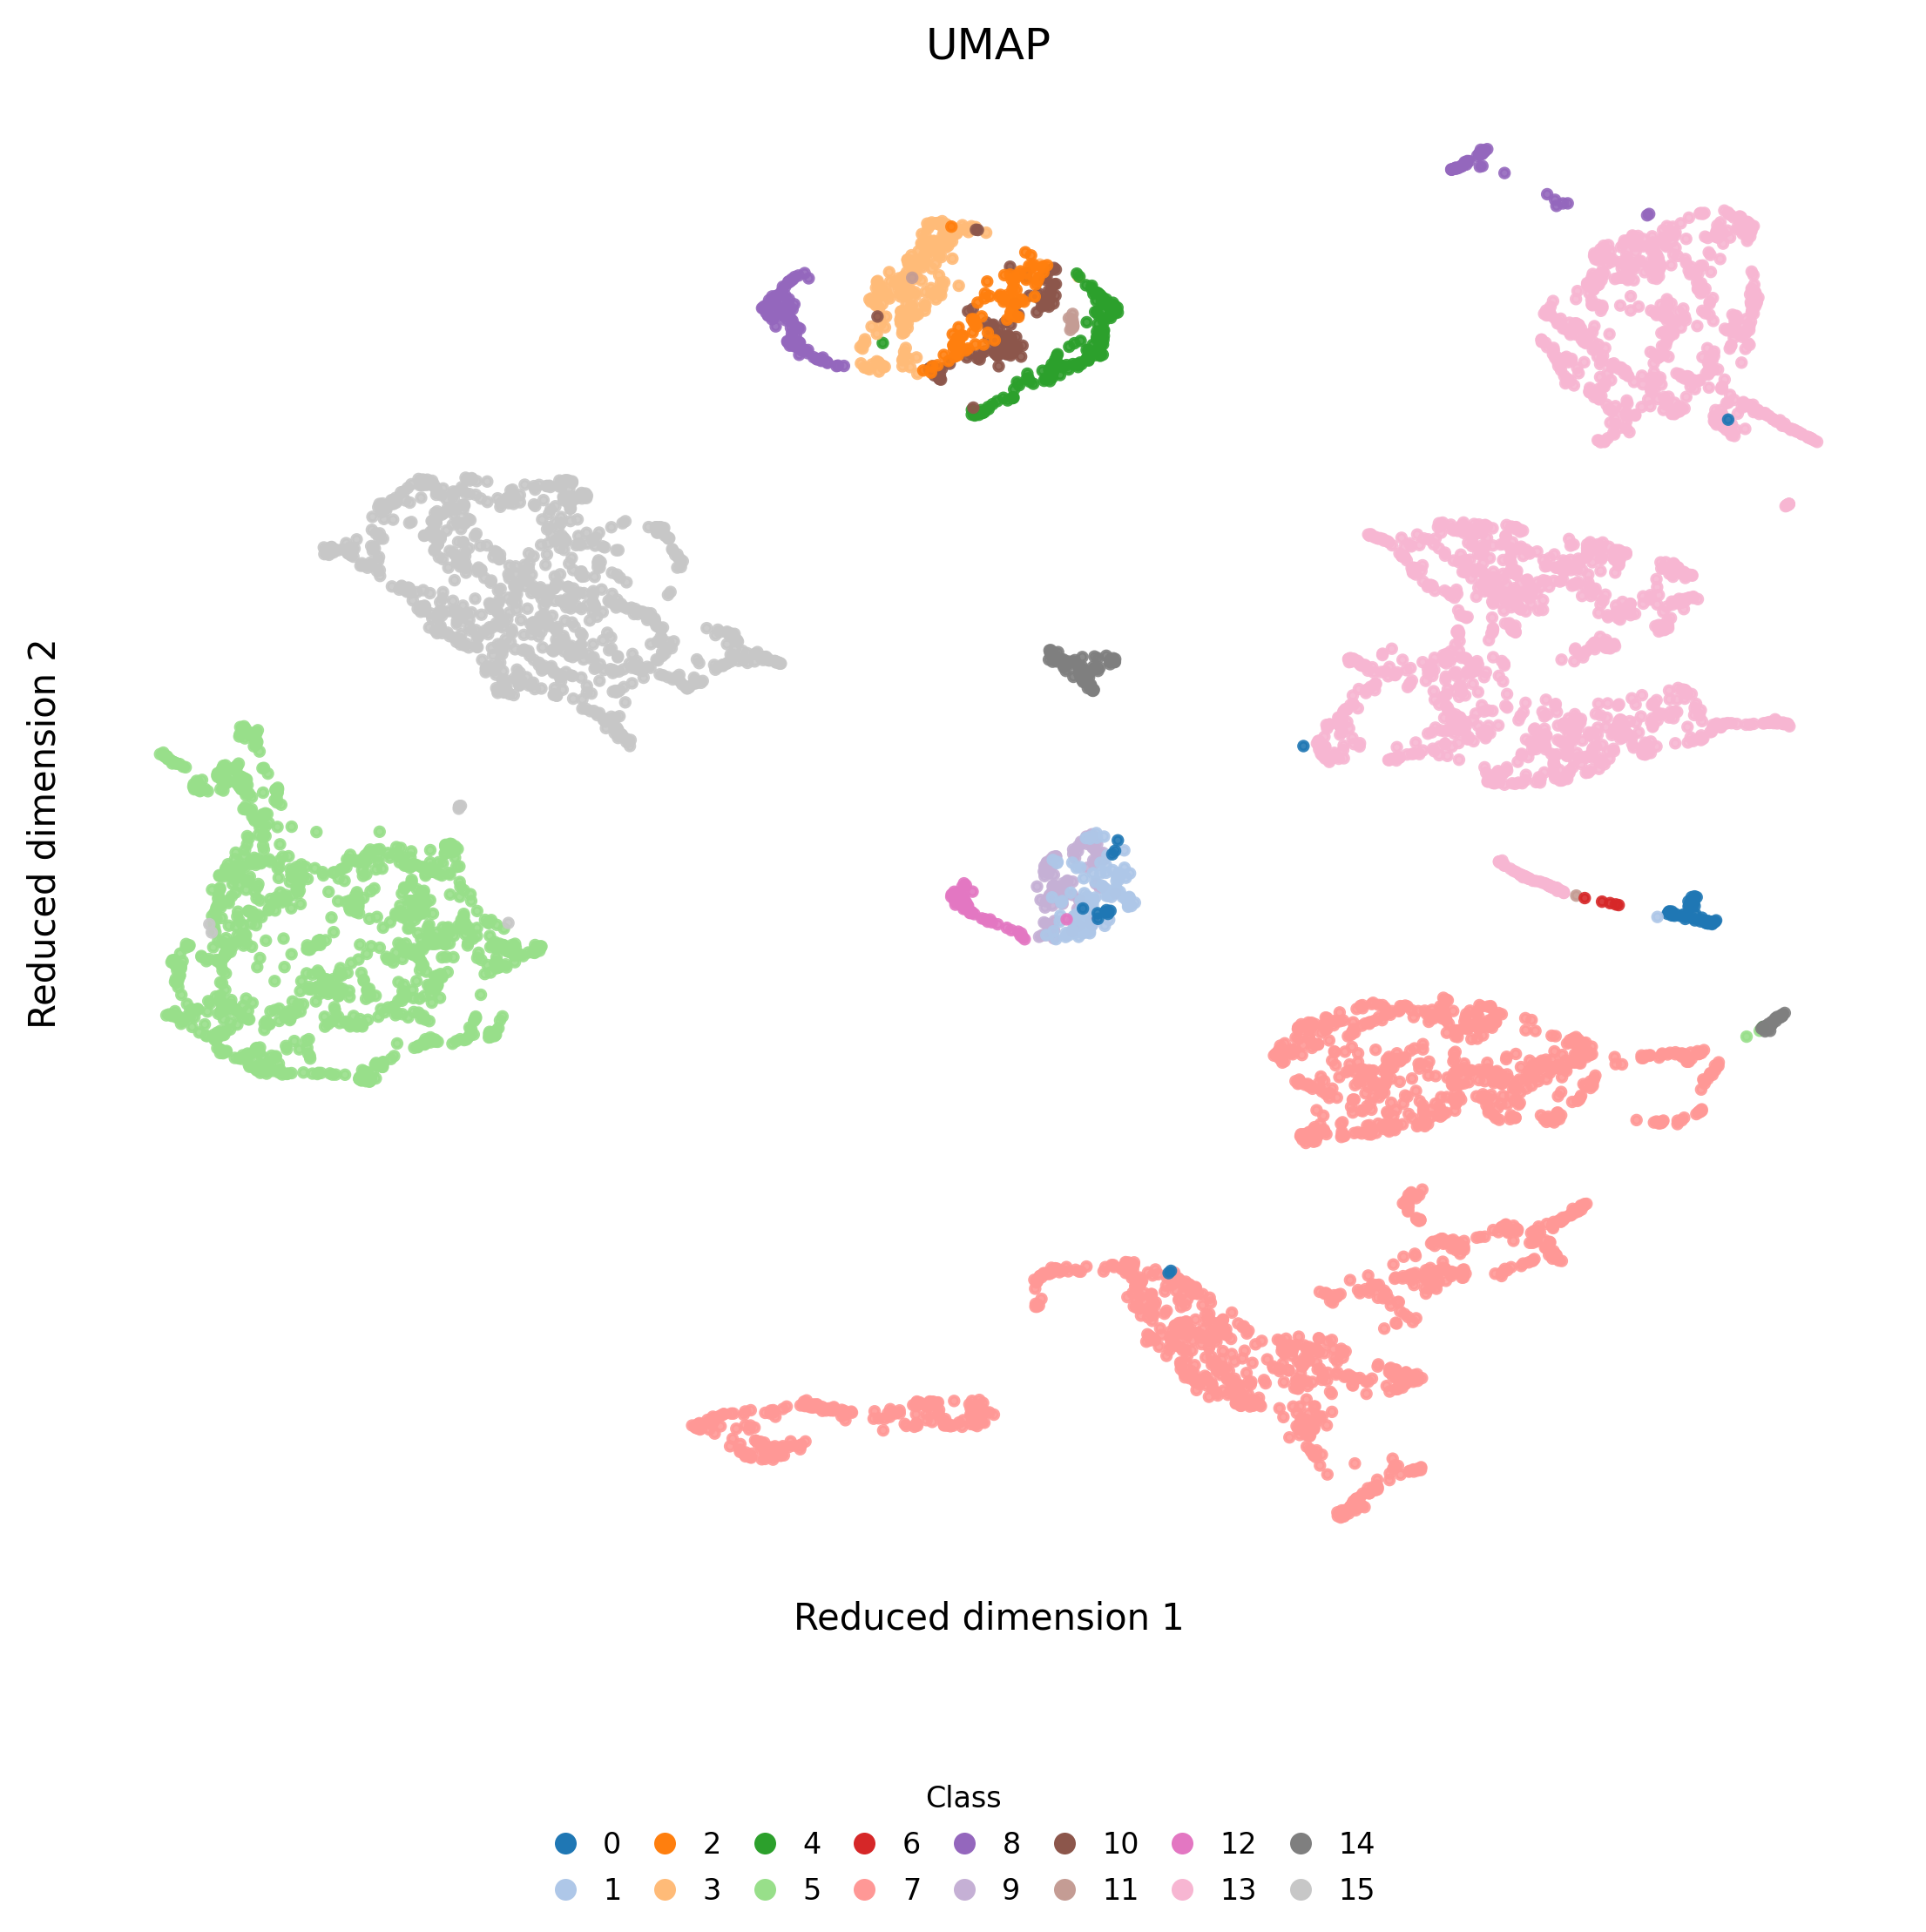

In [39]:
# ===== 4) 作图 =====
fig, ax = plt.subplots(figsize=(9, 8), dpi=300)

sc = ax.scatter(
    emb2d[:, 0], emb2d[:, 1],
    c=inv, cmap=cmap, norm=norm,
    s=6, alpha=0.9
)

# 只要图，不要坐标轴
ax.set_aspect('auto')

# 保留标题和坐标标签
ax.set_title("UMAP", fontsize=12)
ax.set_xlabel("Reduced dimension 1", fontsize=10)
ax.set_ylabel("Reduced dimension 2", fontsize=10)

# 隐藏刻度与边框
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# 图例放在底部（所有类标签）
handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                      markersize=6, markerfacecolor=cmap(i), markeredgecolor='none')
           for i in range(K)]

# 先给底部留点空白，再放图例
plt.subplots_adjust(bottom=0.16)  # 视需要可调大些
legend = fig.legend(
    handles, [str(u) for u in uniq],
    loc='lower center',            # 底部居中
    ncol=8,                        # 16类 → 8列x2行，按需要调成16列一行：ncol=16
    frameon=False,
    title="Class",
    borderaxespad=0.5,
    handlelength=1.0,
    columnspacing=1.0,
    labelspacing=0.6
)

# 保存时尽量紧凑
fig.savefig("umap_scatter.png", dpi=300, bbox_inches='tight', pad_inches=0.2)
# plt.show()

In [73]:
6000 / 3600 * 86400 / 2

72000.0

In [76]:
0.063 * 2 * 1e6 / 86400

1.4583333333333333

In [79]:
50.701 / (10.715 / 1.458)

6.89893215118992

In [74]:
24 / 0.063

380.95238095238096

Note: you may need to restart the kernel to use updated packages.


/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 26463 (\N{CJK UNIFIED IDEOGRAPH-675F}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:34

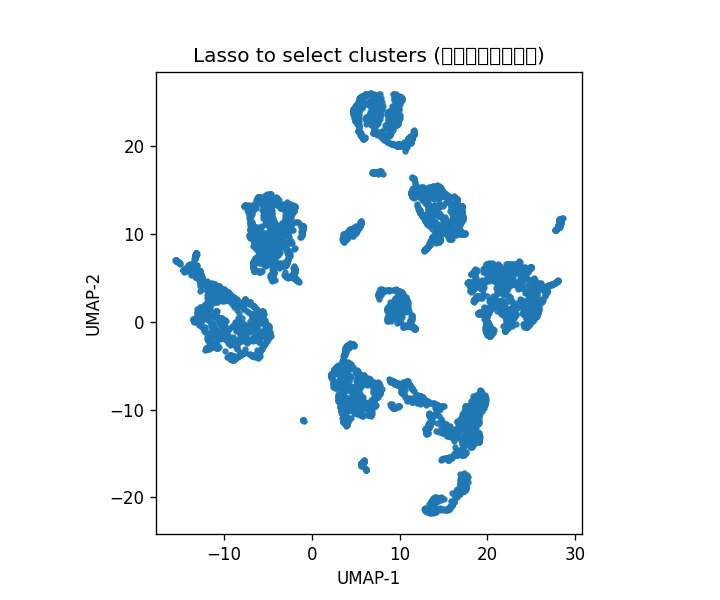

In [15]:
# ==== 依赖与交互后端（JupyterLab 推荐 widget；经典 Notebook 可用 notebook）====
%pip -q install ipympl mplcursors ipywidgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
import mplcursors
from ipywidgets import VBox, HBox, Button, IntText, HTML

# ====== 你的数据 ======
# 你的 UMAP 结果：emb2d 形状 (n, 2)
# 如果你已经有 emb2d / orig_idx，就注释掉这段示例数据
try:
    emb2d
except NameError:
    n = 1500
    rng = np.random.default_rng(42)
    emb2d = np.vstack([
        rng.normal([0,0], 0.4, size=(300,2)),
        rng.normal([5,6], 0.6, size=(500,2)),
        rng.normal([-6,8], 0.5, size=(400,2)),
        rng.normal([8,-5], 0.7, size=(300,2)),
    ])
# 原始数据的行号（如果你的数据经过筛选/洗牌，传入对应的映射）
orig_idx = np.arange(len(emb2d))

# ====== 交互式绘图 ======
fig, ax = plt.subplots(figsize=(6,5), dpi=120)
pts = ax.scatter(emb2d[:,0], emb2d[:,1], s=8, alpha=0.9)
ax.set_aspect('equal', 'box')
ax.set_title("Lasso to select clusters (双击结束一次圈选)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

# 悬浮显示单点 index（emb2d 行号；原始行号用 orig_idx[i]）
cursor = mplcursors.cursor(pts, hover=True)
@cursor.connect("add")
def _show(sel):
    i = sel.index
    sel.annotation.set_text(f"idx={i}, orig={orig_idx[i]}")

# ====== 圈选收集 ======
selected_batches = []  # 每次圈选的 emb2d 行号数组
last_inds = np.array([], dtype=int)

def onselect(verts):
    global last_inds
    path = Path(verts)
    inds = np.nonzero(path.contains_points(emb2d))[0]
    last_inds = inds
    selected_batches.append(inds)
    # 高亮最新一次圈选（把这些点画大一点/更深色）
    sizes = np.full(len(emb2d), 8, dtype=float)
    sizes[inds] = 30
    pts.set_sizes(sizes)
    info_html.value = f"<b>本次圈选</b> {len(inds)} 点；累计批次数：{len(selected_batches)}"

lasso = LassoSelector(ax, onselect)

# ====== 保存控件 ======
info_html = HTML(value="等待圈选…")
btn_save_last = Button(description="保存本次圈选", button_style='info')
btn_save_all  = Button(description="保存全部圈选", button_style='success')
name_last     = IntText(value=0, description="批次号", tooltip="保存哪一批（0 起）")

def save_indices(arr, prefix):
    np.save(f"{prefix}.npy", arr)
    # 简单写 CSV
    np.savetxt(f"{prefix}.csv", arr.reshape(-1,1), fmt="%d", delimiter=",")
    return f"已保存为 {prefix}.npy / {prefix}.csv"

def on_save_last(_):
    # 优先用 name_last 指定的批次；否则用 last_inds
    k = name_last.value
    if 0 <= k < len(selected_batches):
        inds = selected_batches[k]
    else:
        inds = last_inds
    msg = save_indices(orig_idx[inds], prefix="umap_selected_last")
    info_html.value = f"<b>{msg}</b>（条数：{len(inds)}）"

def on_save_all(_):
    # 合并所有圈选并去重
    if not selected_batches:
        info_html.value = "还没有圈选结果。"
        return
    merged = np.unique(np.concatenate(selected_batches))
    msg = save_indices(orig_idx[merged], prefix="umap_selected_merged")
    info_html.value = f"<b>{msg}</b>（合并去重后条数：{len(merged)}）"

btn_save_last.on_click(on_save_last)
btn_save_all.on_click(on_save_all)

display(VBox([
    info_html,
    HBox([btn_save_last, name_last, btn_save_all]),
    fig.canvas  # 把图也放在控件下面，方便交互
]))


In [4]:
traj = Trajectory('/workspace/data/mace-data/all_nointer_0611_forcedel_virial.traj')

In [16]:
from ase.visualize import view

In [17]:
view(traj[5215])

<Popen: returncode: None args: ['/home/yangxin/miniconda3/bin/python', '-m',...>

In [18]:
len(traj[5215])

330

In [19]:
num_atoms = []
for atoms in traj:
    num_atoms.append(len(atoms))

num_atoms = set(num_atoms)

In [36]:
for i, atoms in enumerate(traj):
    if len(atoms) == 648:
        print(i)
        break

53295


428

In [20]:
num_atoms

{330,
 350,
 428,
 440,
 448,
 464,
 476,
 480,
 488,
 536,
 540,
 560,
 579,
 584,
 592,
 624,
 648}

In [42]:
from ase.data.colors import jmol_colors
from ase.io.pov import get_bondpairs
from ase.io import read, write, Trajectory
import subprocess
import os
import numpy as np
from ase.data import covalent_radii

In [102]:
#rotation = '-90x,-90y,0z'
# rotation = '45x,45y,45z'
rotation = '0x,0y,0z'
# (x1, y1, x2, y2), x1, y1 is the position of left-bottom corner, x2, y2 is the position of right-up corner
bbox = (-10, -20, 20, 5)
bbox = (-3, -3, 25, 25)
bbox = (-10, -10, 200, 200)
generic_settings = {
    'rotation'       : rotation, # text string with rotation (default='' )
    'bbox'           : bbox,
    'radii'          : .95, # float, or a list with one float per atom
    'show_unit_cell' : 0,   # 0, 1, or 2 to not show, show, and show all of cell
#    'colors'         : colors,
#    'scale'          : scale,
#    'extra_offset'   : (0., 0.)
}


povray_settings = {
#    'run_povray'     : False, # Run povray or just write .pov + .ini files
    'display'        : False,# Display while rendering
    'pause'          : True, # Pause when done rendering (only if display)
    'transparent'    : True,# Transparent background
    'canvas_width'   : 2000, # Width of canvas in pixels
    'canvas_height'  : None, # Height of canvas in pixels
    'camera_dist'    : 50.,  # Distance from camera to front atom
    'image_plane'    : None, # Distance from front atom to image plane
    'camera_type'    : 'orthographic', #'orthographic', #'perspective', # perspective, ultra_wide_angle
    'point_lights'   : [],             # [[loc1, color1], [loc2, color2],...]
    'area_light'     : [(2., 3., 40.), # location
                        'White',       # color
                        .7, .7, 3, 3], # width, height, Nlamps_x, Nlamps_y
    'background'     : 'White',        # color
    'celllinewidth'  : 0.02,  # Radius of the cylinders representing the cell
    'textures'       : None, 
    'transmittances' : None,
    'bondlinewidth'  : 0.1,
    'bondatoms'      : [],
}

def plot_atoms(plt_atoms, name, render=True, remove_pov=True):
    atoms = plt_atoms.copy()
    atoms.translate((0, 0, 0))
    atoms.wrap()
    
    # control radii
    Z = atoms.get_atomic_numbers()
    colors = jmol_colors[Z]
    radii = covalent_radii[atoms.numbers] * 0.8
    mask = atoms.numbers != 3
    radii[mask] *= 0.5
    transmit = np.zeros_like(atoms.get_atomic_numbers(), dtype=float)
    # transmit = np.where(atoms.numbers != 3, 0.8, 0.0)
    textures = ['jmol'] * len(atoms)

    ase_settings = generic_settings.copy()
    pov_settings = povray_settings.copy()

    ase_settings['colors'] = colors
    ase_settings['radii'] = radii
    pov_settings['bondatoms'] = get_bondpairs(atoms)
    pov_settings['transmittances'] = transmit
    pov_settings['textures'] = textures
    write('{}.pov'.format(name), atoms, povray_settings=pov_settings, **ase_settings)
    if render:
        pov_run = subprocess.run('povray {}.ini'.format(name), 
                                 shell=True, 
                                 stdout=subprocess.DEVNULL, 
                                 stderr=subprocess.DEVNULL)
    if remove_pov:
        os.remove('{}.ini'.format(name))
        os.remove('{}.pov'.format(name))

In [44]:
atoms.numbers

array([8, 6, 8, ..., 9, 9, 9])

In [53]:
np.where(labels==2)

(array([6224, 6225, 6226, 6227, 6228, 6229, 6230, 6231, 6232, 6233, 6234,
        6235, 6236, 6237, 6238, 6239, 6240, 6241, 6242, 6243, 6244, 6245,
        6246, 6247, 6248, 6249, 6250, 6251, 6252, 6253, 6254, 6255, 6256,
        6257, 6258, 6259, 6260, 6261, 6262, 6263, 6264, 6265, 6266, 6267,
        6268, 6269, 6270, 6271, 6272, 6273, 6274, 6275, 6276, 6277, 6278,
        6279, 6280, 6281, 6282, 6283, 6284, 6285, 6286, 6287, 6288, 6289,
        6290, 6291, 6292, 6293, 6294, 6295, 6296, 6297, 6298, 6299, 6300,
        6301, 6302, 6303, 6304, 6305, 6306, 6307, 6308, 6309, 6310, 6311,
        6312, 6313, 6314, 6315, 6316, 6317, 6318, 6319]),)

In [45]:
import numpy as np

In [54]:
plot_atoms(traj[6253], '3')

In [75]:
for i in range(labels.max()+1):
    idx = np.where(labels == i)[0][-1]
    plot_atoms(traj[idx*10], f'{i}')

In [74]:
idx = np.where(labels == 10)[0][-1]
plot_atoms(traj[idx*10], f'{labels.max()}')

In [77]:
class_to_idx

{448: 0,
 480: 1,
 579: 2,
 584: 3,
 648: 4,
 330: 5,
 488: 6,
 428: 7,
 560: 8,
 464: 9,
 624: 10,
 592: 11,
 440: 12,
 476: 13,
 540: 14,
 350: 15}

In [81]:
idx = np.where(labels == 0)[0][-1]
traj[idx*10]

Atoms(symbols='C120H200F6LiO120P', pbc=True, cell=[21.839715869740964, 21.839715869740964, 21.839715869740964], momenta=..., calculator=SinglePointCalculator(...))

In [83]:
traj[idx*10].get_chemical_formula()

'C120H200F6LiO120P'

In [84]:
import re
from typing import Dict, List, Tuple, Optional

def parse_formula(formula: str) -> Dict[str, int]:
    """Parse a chemical formula like 'C120H200F6LiO120P' to element counts."""
    counts = {}
    for el, num in re.findall(r'([A-Z][a-z]?)(\d*)', formula):
        n = int(num) if num else 1
        counts[el] = counts.get(el, 0) + n
    return counts

def solve_ec_dec(C: int, H: int, O: int) -> Optional[Tuple[int, int]]:
    """
    Solve for EC (x) and DEC (y):
      EC:  C3 H4 O3
      DEC: C5 H10 O3
      Equations:
        3x + 5y = C
        4x +10y = H
        3x + 3y = O
    From O: x + y = O/3  => O must be divisible by 3.
    Then x = (5*O/3 - C)/2, y = O/3 - x. Check H as well.
    """
    if O % 3 != 0:
        return None
    O3 = O // 3
    # x = (5*O/3 - C)/2  -> 5*O must be divisible by 3, which it is if O%3==0.
    num = 5 * O3 - C
    if num % 2 != 0:
        return None
    x = num // 2
    y = O3 - x
    if x < 0 or y < 0:
        return None
    # Check H
    if 4 * x + 10 * y != H:
        return None
    return x, y

def solve_ec_dmc(C: int, H: int, O: int) -> Optional[Tuple[int, int]]:
    """
    Solve for EC (x) and DMC (y):
      EC:  C3 H4 O3
      DMC: C3 H6 O3
      Equations:
        3x + 3y = C  -> 3(x+y)=C
        4x + 6y = H
        3x + 3y = O  -> 3(x+y)=O
    From O: x + y = O/3 (O%3==0). Also C must equal O.
    Then x = O - H/2, but derived carefully:
      From H: 4x + 6(O/3 - x) = H -> -2x + 2O = H -> x = (2O - H)/2 = O - H/2
      y = O/3 - x
    """
    if O % 3 != 0:
        return None
    if C != O:
        return None
    if H % 2 != 0:
        return None
    x = O - (H // 2)
    y = O // 3 - x
    if x < 0 or y < 0:
        return None
    # Double-check C/H
    if 3 * (x + y) != C or 4 * x + 6 * y != H:
        return None
    return x, y

def solve_mixture(formula: str) -> Dict[str, int]:
    """Return counts of EC/DEC/DMC for a given formula, or raise if impossible/ambiguous."""
    cnt = parse_formula(formula)
    C, H, O = cnt.get('C', 0), cnt.get('H', 0), cnt.get('O', 0)

    cand = []
    sol_dec = solve_ec_dec(C, H, O)
    if sol_dec is not None:
        x, y = sol_dec
        cand.append(('EC+DEC', {'EC': x, 'DEC': y, 'DMC': 0}))
    sol_dmc = solve_ec_dmc(C, H, O)
    if sol_dmc is not None:
        x, y = sol_dmc
        cand.append(('EC+DMC', {'EC': x, 'DEC': 0, 'DMC': y}))

    if not cand:
        raise ValueError(f"No valid EC+DEC or EC+DMC decomposition for CHO=({C},{H},{O}).")
    if len(cand) > 1:
        # If both fit, return both or choose one as needed.
        # Here we prefer exact-constraint EC+DMC when C==O; otherwise both equal—return both.
        # You can change this policy.
        return dict(cand[0][1]) | {'_mixture': cand[0][0], '_ambiguous': 1}
    mix_name, sol = cand[0]
    sol['_mixture'] = mix_name
    return sol

def solve_many(formulas: List[str]) -> List[Dict[str, int]]:
    return [solve_mixture(f) for f in formulas]

In [ ]:
cnt = parse_formula(traj[0].get_chemical_formula())

In [92]:
for i in range(labels.max()+1):
    idx = np.where(labels == i)[0][-1]
    print(f'Label {i} composition:')
    try:
        print(solve_mixture(traj[idx*10].get_chemical_formula()))
    except:
        print('Not solved')

Label 0 composition:
{'EC': 20, 'DEC': 0, 'DMC': 20, '_mixture': 'EC+DMC'}
Label 1 composition:
{'EC': 12, 'DEC': 0, 'DMC': 28, '_mixture': 'EC+DMC'}
Label 2 composition:
Not solved
Label 3 composition:
{'EC': 20, 'DEC': 20, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 4 composition:
{'EC': 12, 'DEC': 28, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 5 composition:
{'EC': 15, 'DEC': 0, 'DMC': 15, '_mixture': 'EC+DMC'}
Label 6 composition:
{'EC': 12, 'DEC': 0, 'DMC': 28, '_mixture': 'EC+DMC'}
Label 7 composition:
{'EC': 15, 'DEC': 15, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 8 composition:
{'EC': 20, 'DEC': 20, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 9 composition:
{'EC': 20, 'DEC': 0, 'DMC': 20, '_mixture': 'EC+DMC'}
Label 10 composition:
Not solved
Label 11 composition:
{'EC': 20, 'DEC': 20, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 12 composition:
{'EC': 20, 'DEC': 0, 'DMC': 20, '_mixture': 'EC+DMC'}
Label 13 composition:
{'EC': 9, 'DEC': 21, 'DMC': 0, '_mixture': 'EC+DEC'}
Label 14 composition:
Not solved


In [90]:
class_to_idx

{448: 0,
 480: 1,
 579: 2,
 584: 3,
 648: 4,
 330: 5,
 488: 6,
 428: 7,
 560: 8,
 464: 9,
 624: 10,
 592: 11,
 440: 12,
 476: 13,
 540: 14,
 350: 15}

In [87]:
cnt

{'C': 90, 'H': 150, 'O': 90}

In [88]:
traj[0].get_chemical_formula()

'C90H150O90'

In [89]:
print(solve_mixture("C90H150O90"))

{'EC': 15, 'DEC': 0, 'DMC': 15, '_mixture': 'EC+DMC'}


In [79]:
idx

6086

Atoms(symbols='C120H200F6LiO120P', pbc=True, cell=[21.839715869740964, 21.839715869740964, 21.839715869740964], momenta=..., calculator=SinglePointCalculator(...))

In [49]:
np.where(atoms.numbers != 3, 0.8, 0.0)

array([0.8, 0.8, 0.8, ..., 0.8, 0.8, 0.8])

In [47]:
atoms.numbers != 3

array([ True,  True,  True, ...,  True,  True,  True])

In [56]:
plot_atoms(atoms, 'large')

In [103]:
from ase.symbols import atomic_numbers
Z = {
    1: atomic_numbers['C'],
    2: atomic_numbers['F'],
    3: atomic_numbers['H'],
    4: atomic_numbers['Li'],
    5: atomic_numbers['O'],
    6: atomic_numbers['P'],
}

In [104]:
atoms = read('data/ec_dec_55_20w.data', format='lammps-data', Z_of_type=Z)

In [105]:
plot_atoms(atoms, 'giant')

In [ ]:
8 * 30 + 

In [27]:
len(atoms)

4732

In [31]:
atoms

Atoms(symbols='C1272H2326F180Li30O894P30', pbc=True, cell=[37.4581, 37.5139, 37.4209], id=..., type=...)

In [70]:
write('in.data', atoms, format='lammps-data', masses=True)

In [193]:
import importlib

In [194]:
importlib.import_module(sch_128.interactions[0].__class__.__name__)

ModuleNotFoundError: No module named 'RealAgnosticInteractionBlock'

In [ ]:
# 假设你已经有了类名字符串，比如
cls_name = sch_128.interactions[0].__class__.__name__

# 假设该类已经在作用域中（比如 import 过或定义了），你可以用 globals() 或 locals() 来通过类名字符串实例化
cls = globals()[cls_name]
instance = cls()  # 如果需要传入参数请按需要加参数

print(instance)


In [191]:
cls_name = sch_128.interactions[0].__class__.__name__

# 假设该类已经在作用域中（比如 import 过或定义了），你可以用 globals() 或 locals() 来通过类名字符串实例化
cls = globals()[cls_name]

In [192]:
cls

curator.layer._mace_interaction.RealAgnosticInteractionBlock

In [190]:
sch_128.interactions[0].__class__.__name__

'RealAgnosticInteractionBlock'

In [68]:
view(atoms)

<Popen: returncode: None args: ['/home/yangxin/miniconda3/bin/python', '-m',...>

In [197]:
ft_mp_pt_head.heads

['pt_head', 'default']

In [185]:
sch_128 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_128_0709_cue_123_stagetwo.model')
sch_64 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_64_0703_cue_123_stagetwo.model')

ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
ft_mp = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456_default_head_only.model')

ft_off_pt_head = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123_default_head_only.model')
ft_off = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123.model')

dt_mp = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0717_cuequ_epoch20_best.model')
dt_off = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0718_cuequ_off_epoch20_best.model')

# sch_128 = create_model_from_mace(sch_128)
# sch_64 = create_model_from_mace(sch_64)

# # ft_mp_pt_head =create_model_from_mace(ft_mp_pt_head)
# # ft_mp = create_model_from_mace(ft_mp)

# # ft_off_pt_head = create_model_from_mace(ft_off_pt_head)
# # ft_off = create_model_from_mace(ft_off)

# dt_mp = create_model_from_mace(dt_mp)
# dt_off = create_model_from_mace(dt_off)


In [4]:
sch_128 = create_model_from_mace(sch_128)
sch_64 = create_model_from_mace(sch_64)

# ft_mp_pt_head =create_model_from_mace(ft_mp_pt_head)
# ft_mp = create_model_from_mace(ft_mp)

# ft_off_pt_head = create_model_from_mace(ft_off_pt_head)
# ft_off = create_model_from_mace(ft_off)

dt_mp = create_model_from_mace(dt_mp)
dt_off = create_model_from_mace(dt_off)

/opt/conda/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/jit/_check.py:178: Us

In [11]:
sch_64.to('cuda')
sch_64.eval()
sch_64.output_modules[2].model_outputs.append('stress')
sch_64.output_modules[2].model_outputs.append('virial')
sch_64.model_outputs.append('stress')
sch_64.model_outputs.append('virial')

In [2]:
from curator.data import AseDataset, collate_atomsdata, MatScipyNeighborList
from ase.io import Trajectory
from torch.utils.data import DataLoader
import numpy as np


# load models
import torch
from ase.io import read, write, Trajectory
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
from curator.utils import create_model_from_mace

m_sch_128 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_128_0709_cue_123_stagetwo.model')
m_sch_64 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_64_0703_cue_123_stagetwo.model')

m_ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
m_ft_mp = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456_default_head_only.model')

m_ft_off_pt_head = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123_default_head_only.model')
m_ft_off = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123.model')

m_dt_mp = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0717_cuequ_epoch20_best.model')
m_dt_off = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0718_cuequ_off_epoch20_best.model')

sch_128 = create_model_from_mace(m_sch_128)
sch_64 = create_model_from_mace(m_sch_64)

ft_mp_pt_head = create_model_from_mace(m_ft_mp_pt_head)
ft_mp = create_model_from_mace(m_ft_mp)

ft_off_pt_head = create_model_from_mace(m_ft_off_pt_head)
ft_off = create_model_from_mace(m_ft_off)

dt_mp = create_model_from_mace(m_dt_mp)
dt_off = create_model_from_mace(m_dt_off)

/tmp/ipykernel_123321/305365983.py:14: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_sch_128 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_128_0709_cue_123_stagetwo.model')
/tmp/ipykernel_123321/305365983.py:15: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_sch_64 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_64_0703_cue_123_stagetwo.model')
/tmp/ipykernel_123321/305365983.py:17: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
/tmp/ipykernel_12

In [8]:
sch_64.to('cuda')

NeuralNetworkPotential(
  (representation): MACE(
    (embeddings): ModuleDict(
      (onehot_embedding): OneHotAtomEncoding(
        (type_mapper): TypeMapper(symbol_to_type={'H': 0, 'Li': 1, 'C': 2, 'O': 3, 'F': 4, 'P': 5}
      )
      (radial_basis): RadialBasisEdgeEncoding(
        (basis): BesselBasis(cutoff=5.0, num_basis=8, prefactor=0.6324555320336759, trainable=False)
        (cutoff_fn): PolynomialCutoff(cutoff=5.0, power=5.0)
      )
      (sphere_harmonics): SphericalHarmonicEdgeAttrs(
        (sh): SphericalHarmonics()
      )
      (chemical_embedding): AtomwiseLinear(
        (linear): Linear(6x0e -> 64x0e | 384 weights)
      )
    )
    (interactions): ModuleList(
      (0): RealAgnosticInteractionBlock(
        (linear_up): Linear(64x0e -> 64x0e | 4096 weights)
        (conv_tp): TensorProduct(64x0e x 1x0e+1x1o+1x2e+1x3o -> 64x0e+64x1o+64x2e+64x3o | 256 paths | 256 weights)
        (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 256]
        (linear): Linear(64x0

In [13]:
sch_64.representation.embeddings.onehot_embedding.type_mapper.Z_to_index

tensor([-1,  0, -1,  1, -1, -1,  2, -1,  3,  4, -1, -1, -1, -1, -1,  5, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], device='cuda:0')

In [ ]:
batch

{'n_atoms': tensor([330, 330, 330, 330, 330, 330, 330, 330]),
 'atomic_numbers': tensor([1, 1, 1,  ..., 8, 8, 8]),
 'positions': tensor([[ 3.1879, 15.4050, 13.9226],
         [14.1286, 11.0791,  7.9468],
         [15.7933, 11.7659,  7.9506],
         ...,
         [15.3829, 16.1977,  9.0021],
         [11.0417,  5.1440, 11.4913],
         [11.8608,  5.2934, 13.6505]]),
 '_image_index': tensor([0, 0, 0,  ..., 7, 7, 7]),
 'cell': tensor([[17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.],
         [ 0., 17.,  0.],
         [ 0.,  0., 17.],
         [17.,  0.,  0.

In [ ]:
sch_64.output_modules[1].model_outputs.append('virial')
sch_64.output_modules[1].model_outputs.append('stress')

sch_64.model_outputs.append('stress')
sch_64.model_outputs.append('virial')

In [ ]:
# load data
traj = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')
images = [atoms for atoms in traj[::1000]]

dataset = AseDataset(images, cutoff=6.0, transforms=[MatScipyNeighborList(cutoff=6.0, return_cell_displacements=True)])
data_loader = DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=collate_atomsdata)


device = next(sch_64.parameters()).device
dtype = next(sch_64.parameters()).dtype

E_ml, F_ml, S_ml = [], [], []
for i, batch in enumerate(data_loader):
    batch_gpu = {
        k: v.to(device, dtype=dtype)
        if isinstance(v, torch.Tensor) and torch.is_floating_point(v)
        else (v.to(device) if isinstance(v, torch.Tensor) else v)
        for (k, v) in batch.items()
    }
    print(f'Predicting batch # {i}')
    results = sch_64(batch_gpu)
    E_ml.append(results['energy'].detach().cpu())
    F_ml.append(results['forces'].detach().cpu())
    S_ml.append(results['stress'].detach().cpu())
    del results

E_dft, F_dft, S_dft = [], [], []
N = []
V = []

for atoms in images:
    E_dft.append(atoms.get_potential_energy())
    F_dft.append(atoms.get_forces())
    S_dft.append(atoms.get_stress())
    N.append(atoms.get_number_of_atoms())
    V.append(atoms.get_volume())

N = np.asarray(N)
V = np.asarray(V)

E_dft = np.asarray(E_dft)
F_dft = np.concatenate(F_dft).flatten()
S_dft = np.concatenate(S_dft)

F_ml = F_ml.numpy().flatten()
S_ml = S_ml.numpy()
E_ml = E_ml.numpy()

E_ml = torch.cat(E_ml)
F_ml = torch.cat(F_ml)
S_ml = torch.cat(S_ml)

S_ml = np.concatenate(S_ml)
S_dft = np.concatenate(S_dft)
S_ml = S_ml.reshape(-1, 6)
S_dft = S_dft.reshape(-1, 6)

V_dft = S_dft * V.reshape(-1, 1)
V_ml = S_ml * V.reshape(-1, 1)

V_dft = V_dft.flatten()
V_ml = V_ml.flatten()

E_dft = E_dft / N
E_ml = E_ml / N


# plot
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros", "Arial", "DejaVu Sans"],
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, axes = plt.subplots(1,3, figsize=(16, 5.5))

def plot_ax_with_seaborn(ax, x, y, xlabel, ylabel, color):

    xmin = min(x.min(), y.min())
    xmax = max(x.max(), y.max())
    pad  = 0.05 * (xmax - xmin)
    lims = [xmin - pad, xmax + pad]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Scatter plot
    ax.scatter(x, y, s=10, color=color, alpha=0.5, edgecolors="none")

    # 1D KDE along x-axis
    ax_kde_x = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
    sns.kdeplot(x, ax=ax_kde_x, color=color, fill=True, linewidth=1, alpha=0.3)
    ax_kde_x.axis("off")

    # 1D KDE along y-axis (horizontal)
    ax_kde_y = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
    sns.kdeplot(y, ax=ax_kde_y, color=color, fill=True, linewidth=1, vertical=True, alpha=0.3)
    ax_kde_y.axis("off")

    locator = MaxNLocator(nbins=6, integer=True)  # nbins 改大小控制刻度个数
    ax.xaxis.set_major_locator(locator)
    ax.yaxis.set_major_locator(locator)

    # 让 locator 真正算出 tick（后端需要 draw 一次）
    ax.figure.canvas.draw_idle()
    ticks = ax.get_xticks()
    interval = ticks[1] - ticks[0]
    lims = [ticks[0] - 0.5 * interval, ticks[-1] + 0.5 * interval]
    ax.plot(lims, lims, "k-", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    # Calculate RMSE between x and y
    import numpy as np
    rmse = np.sqrt(np.mean((x - y) ** 2))
    # Annotate the RMSE value in the upper left corner
    ax.annotate(f'RMSE = {rmse:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=12, ha='left', va='top',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plot_ax_with_seaborn(
    ax=axes[0], 
    x=E_dft[::1], 
    y=E_ml[::1], 
    xlabel='DFT energy (eV)', 
    ylabel='ML energy (eV)', 
    color='red',
)

plot_ax_with_seaborn(
    ax=axes[1], 
    x=F_dft[::1], 
    y=F_ml[::1], 
    xlabel='DFT forces (eV/Å)', 
    ylabel='ML forces (eV/Å)', 
    color='green',
)

plot_ax_with_seaborn(
    ax=axes[2], 
    x=V_dft[::1], 
    y=V_ml[::1], 
    xlabel='DFT virial (eV)', 
    ylabel='ML virial (eV)', 
    color='blue',
)

plt.subplots_adjust(wspace=0.55)
plt.tight_layout()
plt.savefig('sch_64.jpg', dpi=500)

/tmp/ipykernel_123321/599891468.py:2: ResourceWarning: unclosed file <_io.BufferedReader name='mace-data/all_nointer_0611_forcedel_virial.traj'>
  traj = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')
/home/xinyang/curator/curator/data/_neighborlist.py:284: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  outputs[properties.cell_displacements] = torch.as_tensor(S.dot(cell), dtype=pos.dtype)


Predicting batch # 0
Predicting batch # 1
Predicting batch # 2


In [24]:
sch_64(batch_gpu)

{'forces': tensor([[ 0.0298,  0.0631,  0.0143],
         [-0.0520, -0.0863, -0.0396],
         [-0.0609, -0.1791,  0.0774],
         ...,
         [-0.4034, -0.2251,  0.3481],
         [ 0.0692,  0.5904,  0.2333],
         [ 0.6275, -0.2742, -0.5190]], device='cuda:0', dtype=torch.float64,
        grad_fn=<AddBackward0>),
 'energy': tensor([-4.9188,  0.5393], device='cuda:0', dtype=torch.float64,
        grad_fn=<ScatterAddBackward0>),
 'stress': tensor([[-0.0069, -0.0090, -0.0072, -0.0003,  0.0008, -0.0003],
         [ 0.0012,  0.0046, -0.0030, -0.0007, -0.0022, -0.0002]],
        device='cuda:0', dtype=torch.float64, grad_fn=<IndexBackward0>),
 'virial': tensor([[ 33.9222,  44.0578,  35.4397,   1.2924,  -3.9430,   1.6624],
         [ -5.6886, -22.6515,  14.6444,   3.5367,  10.8926,   1.0100]],
        device='cuda:0', dtype=torch.float64, grad_fn=<IndexBackward0>)}

In [4]:
traj = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')
images = [atoms for atoms in traj[::10]]

dataset = AseDataset(images, cutoff=6.0, transforms=[MatScipyNeighborList(cutoff=6.0, return_cell_displacements=True)])
data_loader = DataLoader(dataset, batch_size=8, shuffle=False, collate_fn=collate_atomsdata)

In [6]:
batch = next(iter(data_loader))

In [9]:
batch['masks']

{'energy': tensor([True, True, True, True, True, True, True, True]),
 'forces': tensor([True, True, True, True, True, True, True, True]),
 'stress': tensor([True, True, True, True, True, True, True, True]),
 'virial': tensor([True, True, True, True, True, True, True, True])}

In [7]:
batch.keys()

dict_keys(['n_atoms', 'atomic_numbers', 'positions', '_image_index', 'cell', '_edge_index', '_edge_difference', '_cell_displacements', '_n_pairs', 'energy', 'forces', 'stress', 'virial', 'targets', 'masks', 'task', 'weight', 'meta'])

In [14]:
import os

import numpy as np
import seaborn as sns
import torch
from ase.io import Trajectory
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from torch.utils.data import DataLoader

from curator.data import AseDataset, MatScipyNeighborList, collate_atomsdata
from curator.utils import create_model_from_mace

os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"


def _plot_ax_with_seaborn(ax, x, y, xlabel, ylabel, color):
    xmin = min(x.min(), y.min())
    xmax = max(x.max(), y.max())
    pad = 0.05 * (xmax - xmin)
    lims = [xmin - pad, xmax + pad]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.scatter(x, y, s=10, color=color, alpha=0.5, edgecolors="none")

    ax_kde_x = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
    sns.kdeplot(x, ax=ax_kde_x, color=color, fill=True, linewidth=1, alpha=0.3)
    ax_kde_x.axis("off")

    ax_kde_y = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
    sns.kdeplot(y, ax=ax_kde_y, color=color, fill=True, linewidth=1, vertical=True, alpha=0.3)
    ax_kde_y.axis("off")

    locator = MaxNLocator(nbins=6, integer=True)
    ax.xaxis.set_major_locator(locator)
    ax.yaxis.set_major_locator(locator)

    ax.figure.canvas.draw_idle()
    ticks = ax.get_xticks()
    interval = ticks[1] - ticks[0]
    lims = [ticks[0] - 0.5 * interval, ticks[-1] + 0.5 * interval]
    ax.plot(lims, lims, "k-", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    rmse = np.sqrt(np.mean((x - y) ** 2))
    ax.annotate(
        f"RMSE = {rmse:.3f}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=12,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_parity(
    model_path,
    traj_path,
    output_path,
    *,
    device="cuda",
    batch_size=8,
    cutoff=6.0,
    traj_stride=10,
    sample_stride=100,
):
    """
    Load a MACE model and trajectory data, run inference, and save parity plots.
    Only model_path and traj_path are required; the rest are optional tweaks.
    """
    mace_state = torch.load(model_path, map_location="cpu")
    model = create_model_from_mace(mace_state).to(device)
    model.eval()
    target_dtype = next(model.parameters()).dtype

    traj = Trajectory(traj_path)
    images = [atoms for atoms in traj[::traj_stride]]

    dataset = AseDataset(
        images,
        cutoff=cutoff,
        transforms=[MatScipyNeighborList(cutoff=cutoff, return_cell_displacements=True)],
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_atomsdata)

    energies_ml, forces_ml, stresses_ml = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch_device = {k: v.to(device=device, dtype=target_dtype) for k, v in batch.items() if isinstance(v, torch.Tensor)}
            results = model(batch_device)
            energies_ml.append(results["energy"].detach().cpu())
            forces_ml.append(results["forces"].detach().cpu())
            stresses_ml.append(results["stress"].detach().cpu())

    energies_ml = torch.cat(energies_ml).numpy()
    forces_ml = torch.cat(forces_ml).numpy().reshape(-1)
    stresses_ml = torch.cat(stresses_ml).numpy()

    energies_dft = np.array([atoms.get_potential_energy() for atoms in images])
    forces_dft = np.concatenate([atoms.get_forces() for atoms in images]).reshape(-1)
    stresses_dft = np.concatenate([atoms.get_stress() for atoms in images])
    natoms = np.array([atoms.get_number_of_atoms() for atoms in images])
    volumes = np.array([atoms.get_volume() for atoms in images])

    stresses_ml = stresses_ml.reshape(-1, 6)
    stresses_dft = stresses_dft.reshape(-1, 6)
    virials_ml = (stresses_ml * volumes.reshape(-1, 1)).reshape(-1)
    virials_dft = (stresses_dft * volumes.reshape(-1, 1)).reshape(-1)

    energies_ml = energies_ml / natoms
    energies_dft = energies_dft / natoms

    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["TeX Gyre Heros", "Arial", "DejaVu Sans"],
            "axes.labelsize": 14,
            "axes.titlesize": 14,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
        }
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

    _plot_ax_with_seaborn(
        ax=axes[0],
        x=energies_dft[::sample_stride],
        y=energies_ml[::sample_stride],
        xlabel="DFT energy (eV)",
        ylabel="ML energy (eV)",
        color="red",
    )

    _plot_ax_with_seaborn(
        ax=axes[1],
        x=forces_dft[::sample_stride],
        y=forces_ml[::sample_stride],
        xlabel="DFT forces (eV/Å)",
        ylabel="ML forces (eV/Å)",
        color="green",
    )

    _plot_ax_with_seaborn(
        ax=axes[2],
        x=virials_dft[::sample_stride],
        y=virials_ml[::sample_stride],
        xlabel="DFT virial (eV)",
        ylabel="ML virial (eV)",
        color="blue",
    )

    plt.subplots_adjust(wspace=0.55)
    plt.tight_layout()
    fig.savefig(output_path, dpi=500)

    return fig, axes

In [1]:
from plot_parity import plot_parity

/home/yangxin/miniconda3/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/yangxin/curator/curator/layer/_cuequivariance_wrapper.py:19: RuntimeWarning: cuequivariance could not be loaded (ModuleNotFoundError("No module named 'cuequivariance.group_theory'")); cueq acceleration disabled.
  warnings.warn(
/home/yangxin/curator/curator/layer/_cuequivariance_wrapper.py:61: UserWarning: cuequivariance is not available. Cuequivariance acceleration will be disabled.
  warnings.warn("cuequivariance is not available. Cuequivariance acceleration will be disabled.")


In [4]:
from ase.io import read, write, Trajectory

In [5]:
traj = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')

In [7]:
traj[0].get_stress()

array([-0.00544793, -0.00710192, -0.00571957, -0.00024003,  0.00060368,
       -0.00028471])

In [10]:
import torch
from curator.utils import create_model_from_mace

ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
ft_mp_pt_head = create_model_from_mace(ft_mp_pt_head)

/tmp/ipykernel_30985/2672010462.py:4: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/mi

In [ ]:
ft_mp_pt_head.output_modules[2].model_outputs=

GradientOutput(grad_on_edge_diff=True, grad_on_positions=False, model_outputs=['energy', 'forces'])

/home/yangxin/curator/electrolytes/plot_parity.py:78: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  mace_state = torch.load(model_path, map_location="cpu")
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/tor

(<Figure size 1060x550 with 2 Axes>,
 array([<Axes: xlabel='DFT energy (eV)', ylabel='ML energy (eV)'>,
        <Axes: xlabel='DFT forces (eV/Å)', ylabel='ML forces (eV/Å)'>],
       dtype=object))

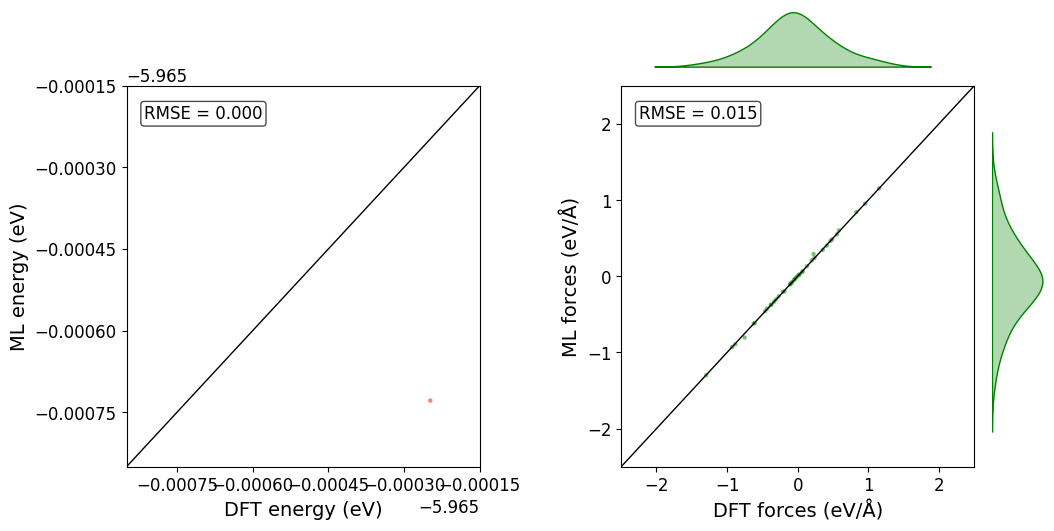

In [2]:
plot_parity(
    model_path='mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model',
    traj_path='mace-data/all_nointer_0611_forcedel_virial.traj',
    output_path='ft_mp_pt_head.pdf',
    device='cuda',
    traj_stride=100,
    sample_stride=100,
    batch_size=2,
    max_frames=4,
)

In [ ]:
dataset = AseDataset(
    images,
    cutoff=cutoff,
    transforms=[MatScipyNeighborList(cutoff=cutoff, return_cell_displacements=True)],
)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_atomsdata)

In [199]:
g1 = jointplot_with_line(
    E_dft[::10], E_ml[::10],
    xlabel="DFT energy [eV]",
    ylabel="ML energy [eV]",
    title="Energy Errors",
    color="red",
)

In [66]:
pw.overwrite_axisgrid()

In [70]:
g1.fig.get_size_inches()

array([6., 6.])

In [71]:
if not hasattr(g1, "_figsize"):
    g1._figsize = g1.fig.get_size_inches() 
p1 = pw.load_seaborngrid(g1)

if not hasattr(g2, "_figsize"):
    g2._figsize = g2.fig.get_size_inches() 
p2 = pw.load_seaborngrid(g2)

if not hasattr(g3, "_figsize"):
    g3._figsize = g3.fig.get_size_inches() 
p3 = pw.load_seaborngrid(g3)

p = p1 | p2 | p3
fig = p.get_figure()
fig.set_size_inches(12, 4)   # 比如 12x4 英寸，你可以按需要改
fig.set_dpi(300)             # 300 dpi 一般论文也够用了

# 再保存
fig.savefig("sch_64.jpg", bbox_inches="tight")

AttributeError: 'Bricks' object has no attribute 'get_figure'

In [40]:
F_dft.flatten()

array([ 0.022527  ,  0.052509  , -0.005728  , ..., -1.08827886,
       -0.47412162, -0.25194661])

In [19]:
sch_64.to('cuda')
sch_64.eval()
sch_64.output_modules[2].model_outputs.append('stress')
sch_64.output_modules[2].model_outputs.append('virial')
sch_64.model_outputs.append('stress')
sch_64.model_outputs.append('virial')

In [44]:
from mace.calculators import MACECalculator

In [48]:
mlcalc = MACECalculator(models=dt_mp)

No dtype selected, switching to float64 to match model dtype.


In [40]:
ft_mp_pt_head.atomic_energies_fn.atomic_energies[0].shape

torch.Size([84])

In [43]:
ft_mp_pt_head.atomic_energies_fn.atomic_energies[1]

tensor([ -2.9622,  -1.6900,   0.0000,   0.0000, -10.5880,   0.0000,  -6.2837,
         -5.8527,   0.0000,   0.0000,   0.0000,   0.0000,  -0.9754,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000],
       dtype=torch.float64)

In [3]:
dt_mp

ScaleShiftMACE(
  (node_embedding): LinearNodeEmbeddingBlock(
    (linear): Linear(6x0e -> 64x0e | 384 weights)
  )
  (radial_embedding): RadialEmbeddingBlock(
    (bessel_fn): BesselBasis(r_max=5.0, num_basis=8, trainable=False)
    (cutoff_fn): PolynomialCutoff(p=5, r_max=5.0)
  )
  (spherical_harmonics): SphericalHarmonics()
  (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-2.9208, -0.9961, -10.7186, -6.2126, -5.9764, -0.9961]])
  (interactions): ModuleList(
    (0): RealAgnosticInteractionBlock(
      (linear_up): Linear(64x0e -> 64x0e | 4096 weights)
      (conv_tp): TensorProduct(64x0e x 1x0e+1x1o+1x2e+1x3o -> 64x0e+64x1o+64x2e+64x3o | 256 paths | 256 weights)
      (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 256]
      (linear): Linear(64x0e+64x1o+64x2e+64x3o -> 64x0e+64x1o+64x2e+64x3o | 16384 weights)
      (skip_tp): FullyConnectedTensorProduct(64x0e+64x1o+64x2e+64x3o x 6x0e -> 64x0e+64x1o+64x2e+64x3o | 98304 paths | 98304 weights)
      (reshape): reshape_irreps

In [51]:
atoms = images[-1]

In [52]:
atoms.calc = mlcalc

In [53]:
atoms.get_potential_energy()

-2832.287114264289

In [ ]:
dt_mp.representation

NeuralNetworkPotential(
  (representation): MACE(
    (embeddings): ModuleDict(
      (onehot_embedding): OneHotAtomEncoding(
        (type_mapper): TypeMapper(symbol_to_type={'H': 0, 'Li': 1, 'C': 2, 'O': 3, 'F': 4, 'P': 5}
      )
      (radial_basis): RadialBasisEdgeEncoding(
        (basis): BesselBasis(cutoff=5.0, num_basis=8, prefactor=0.6324555320336759, trainable=False)
        (cutoff_fn): PolynomialCutoff(cutoff=5.0, power=5.0)
      )
      (sphere_harmonics): SphericalHarmonicEdgeAttrs(
        (sh): SphericalHarmonics()
      )
      (chemical_embedding): AtomwiseLinear(
        (linear): Linear(6x0e -> 64x0e | 384 weights)
      )
    )
    (interactions): ModuleList(
      (0): RealAgnosticInteractionBlock(
        (linear_up): Linear(64x0e -> 64x0e | 4096 weights)
        (conv_tp): TensorProduct(64x0e x 1x0e+1x1o+1x2e+1x3o -> 64x0e+64x1o+64x2e+64x3o | 256 paths | 256 weights)
        (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 256]
        (linear): Linear(64x0

In [61]:
find_layer_by_name_recursive(dt_mp.representation, 'readout_mlp')

ModuleList(
  (0): Linear(64x0e+64x1o+64x2e -> 1x0e | 64 weights)
  (1): AtomwiseNonLinear(
    (linear_1): Linear(64x0e -> 16x0e | 1024 weights)
    (non_linearity): Activation [x] (16x0e -> 16x0e)
    (linear_2): Linear(16x0e -> 1x0e | 16 weights)
  )
)

In [6]:
# get features
from curator.select import FeatureExtractor, FeatureStatistics
from curator.data import AseDataset
dataset = AseDataset(images, cutoff=5.0)
extractor = FeatureExtractor(dt_mp)
feat_stats = FeatureStatistics([dt_mp], dataset)

In [8]:
feats = feat_stats.get_features()

/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


: 

In [13]:
from curator.layer.utils import find_layer_by_name_recursive

In [14]:
layer = find_layer_by_name_recursive(dt_mp, 'readouts[-1]')

In [27]:
mace_model = dt_mp

In [32]:
create_model_from_mace(dt_mp)

/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/

NeuralNetworkPotential(
  (representation): MACE(
    (embeddings): ModuleDict(
      (onehot_embedding): OneHotAtomEncoding(
        (type_mapper): TypeMapper(symbol_to_type={'H': 0, 'Li': 1, 'C': 2, 'O': 3, 'F': 4, 'P': 5}
      )
      (radial_basis): RadialBasisEdgeEncoding(
        (basis): BesselBasis(cutoff=5.0, num_basis=8, prefactor=0.6324555320336759, trainable=False)
        (cutoff_fn): PolynomialCutoff(cutoff=5.0, power=5.0)
      )
      (sphere_harmonics): SphericalHarmonicEdgeAttrs(
        (sh): SphericalHarmonics()
      )
      (chemical_embedding): AtomwiseLinear(
        (linear): Linear(6x0e -> 64x0e | 384 weights)
      )
    )
    (interactions): ModuleList(
      (0): RealAgnosticInteractionBlock(
        (linear_up): Linear(64x0e -> 64x0e | 4096 weights)
        (conv_tp): TensorProduct(64x0e x 1x0e+1x1o+1x2e+1x3o -> 64x0e+64x1o+64x2e+64x3o | 256 paths | 256 weights)
        (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 256]
        (linear): Linear(64x0

In [12]:
features = feat_stats.get_features()

KeyError: 'node_attrs'

In [15]:
layers.children()

<generator object Module.children at 0x76c39c187b90>